# Initialize the notebook and download some molecules

In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


2025-12-05 13:46:54,474 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


# Examine the bin edges 

In [3]:
Opacity.get_available_species()

name,species,charge,line_list,version,size_gb,path,index
float64,float64,float64,float64,float64,float64,float64,int64


In [2]:
pressures = np.geomspace(1e-6, 1, 100)
temperatures = 600 * (pressures / 0.1) ** 0.08
species = ['H2O', 'CH4', 'NH3','CO2','CO']
binned_opacities = []

for spec in species:
    op = Opacity.load_species_from_name(spec)
    binned_opacities.append(
        op.get_binned_interpolator(np.geomspace(0.82, 1.64, 200), temperatures, pressures) )
mmw_neptune = 10  # [AMU]
chem = FastchemWrapper(np.array([600]), np.array([0.01]))
vmr = chem.vmr()
weights = chem.get_weights()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [4]:
S22_speclc_bin_edges = np.array([#0.81077,
                                 0.8329,
                                 # 0.84519,
                                 0.84765,
                                 # 0.85748,
                                 # 0.86977,
                          0.87961,0.8919,0.90173,
                          0.91402,0.93123,0.94598,
                          0.95828,0.96811,0.9804,
                          0.99761,1.0099,1.01974,1.03449,
                          1.04678,1.06153,1.07382,#1.08611,
                          1.09595,1.10578,1.11807,1.13037])*u.micron

S22_speclc_bin_edges = np.array([0.8329,
0.84765,
0.87961,
0.8919,
0.90173,
0.91402,
0.93123,
0.94598,
0.95828,
0.96811,
0.9804,
0.99761,
1.0099,
1.01974,
1.03449,
1.06153,
1.09595,
1.10578,
1.11807,
1.13037,])*u.micron

In [5]:
F21_speclc_bin_edges = np.array([1.14296 ,
1.15263 ,
1.16318 ,
1.18179 ,
1.21123 ,
1.22782 ,
1.2374 ,
1.25408 ,
1.26804 ,
1.28748 ,
1.32515 ,
1.33291 ,
1.34682 ,
1.37287 ,
1.39266 ,
1.40199 ,
1.4164 ,
1.43361 ,
1.45982 ,
1.48938 ,
1.51175 ,
1.53161 ,
1.55509 ,
1.56757 ,
1.6138 ,
1.63867 ,])*u.micron

108
[1.14295639 1.14758925 1.15222211 1.15685497 1.16148784 1.1661207
 1.17075356 1.17538642 1.18001929 1.18465215 1.18928501 1.19391788
 1.19855074 1.2031836  1.20781646 1.21244933 1.21708219 1.22171505
 1.22634791 1.23098078 1.23561364 1.2402465  1.24487937 1.24951223
 1.25414509 1.25877795 1.26341082 1.26804368 1.27267654 1.2773094
 1.28194227 1.28657513 1.29120799 1.29584085 1.30047372 1.30510658
 1.30973944 1.31437231 1.31900517 1.32363803 1.32827089 1.33290376
 1.33753662 1.34216948 1.34680234 1.35143521 1.35606807 1.36070093
 1.36533379 1.36996666 1.37459952 1.37923238 1.38386525 1.38849811
 1.39313097 1.39776383 1.4023967  1.40702956 1.41166242 1.41629528
 1.42092815 1.42556101 1.43019387 1.43482674 1.4394596  1.44409246
 1.44872532 1.45335819 1.45799105 1.46262391 1.46725677 1.47188964
 1.4765225  1.48115536 1.48578822 1.49042109 1.49505395 1.49968681
 1.50431968 1.50895254 1.5135854  1.51821826 1.52285113 1.52748399
 1.53211685 1.53674971 1.54138258 1.54601544 1.5506483  1.55

/var/folders/5d/qc7qt63j6zgdm0s2hz9ty6y80000gn/T/ipykernel_45913/3702619521.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 In using`.pcolormesh`, [display pixels] / [data pixels] =
[274. 350.] / [162 108] = [1.68845316 3.24074074] ('Time', 'Wavelength')
Is less than the suggested threshold of 2.

This suggests that aliasing/moiré might be a problem, where too many
data pixels are trying to be displayed with too few pixels, and the
choices `matplotlib` makes for how to do that might not be intuitive.

Here are possible solutions:
    - Use `.bin()` to decrease the number of data pixels in wavelength
    and/or time, effectively averaging before displaying, rather than
    asking `matplotlib` to decide how to visually average adjacent data.
    - Increase the `dpi` of the figure in which this appears, so there are
    enough display pixels to represent all the data pixels being shown.
    - Use `.imshow()` instead of `.pcolormesh`, which can do better
    built-in handling of antialiasing for large data arrays. Since `.imshow()`
    can only show uniform wavelength and time grids, non-uniform grids will
 

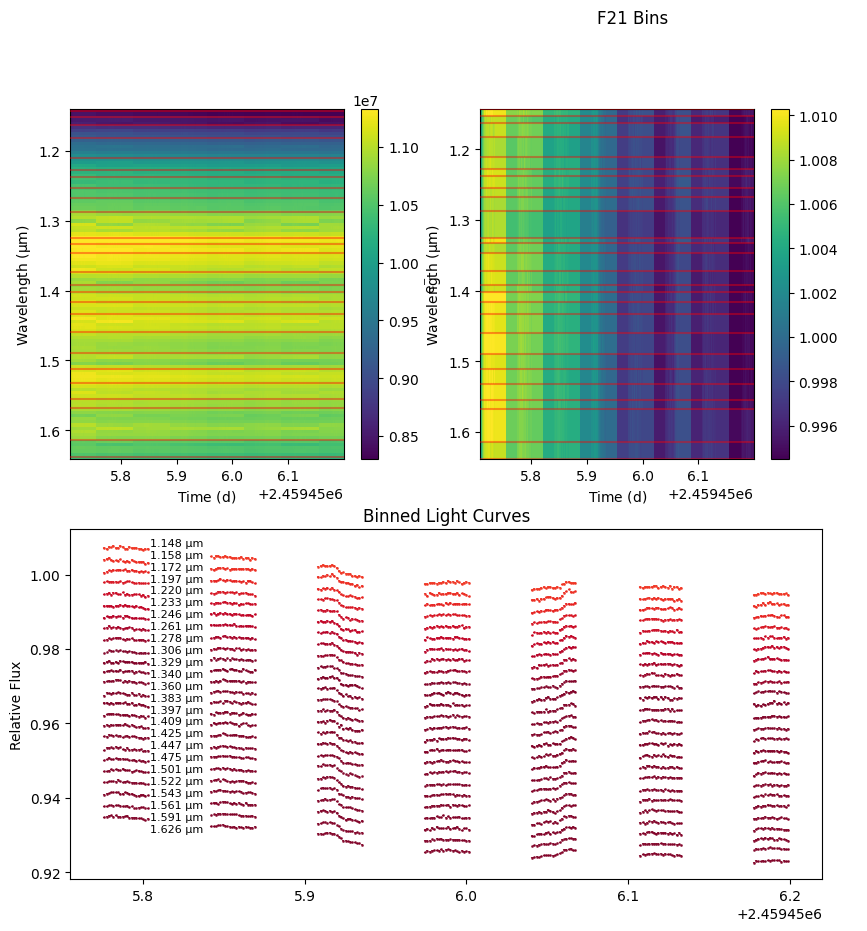

<Figure size 640x480 with 0 Axes>

In [18]:
for visit in ['F21']:
    # Extract exposure times and mid-transit times from the dictionary
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    expTime = visits[f'{visit}']['exp (s)'].value
    if visit == 'F21':
        bin_edges = F21_speclc_bin_edges.value
    if visit == 'S22':
        bin_edges = S22_speclc_bin_edges.value

    # Create a custom grid layout
    fig = plt.figure(figsize=(15, 10))
    plt.tight_layout()
    plt.suptitle(f'{visit} Bins')

    # Define the grid layout
    ax1 = plt.subplot2grid((2, 3), (0, 0))  # Top left (imshow 1)
    ax2 = plt.subplot2grid((2, 3), (0, 1))  # Top middle (imshow 2)
    ax3 = plt.subplot2grid((2, 3), (1, 0), colspan=2)  # Bottom left (merged plot)
    # ax4 = plt.subplot2grid((2, 3), (0, 2))  # Top right (1D Spectra)
    # ax5 = plt.subplot2grid((2, 3), (1, 2))  # Bottom right (Opacities)

    # Set titles
    # ax4.set_title('1D Spectra')
    # ax5.set_title('Opacities')
    ax3.set_title('Binned Light Curves')
    ax3.set_ylabel('Relative Flux')

    for edge in bin_edges:
        ax1.axhline(edge, color='r', zorder=100,alpha=0.4)
        ax2.axhline(edge, color='r', zorder=100,alpha=0.4)
        # ax5.axvline(edge, color='r', zorder=100,alpha=0.4)
        # ax4.axvline(edge, color='r', zorder=100,alpha=0.4)

    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")

    print(len(rainbow.wavelength))
    print(rainbow.wavelength)
    # print(np.nanmedian(rainbow.wavelength.value[:-1]-rainbow.wavelength.value[1:]) )
    binned = rainbow.normalize().bin(wavelength_edges=bin_edges * u.micron)
    img_date = binned.time.value
    orbit = np.zeros_like(img_date)

    # if direction == 'Forward':
    rainbow.pcolormesh(ax=ax1)
    binned.pcolormesh(ax=ax2)

    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]

    for o in np.unique(orbit[orbit >= 0]):
        first_index = np.where(orbit == o)[0][0]
        rainbow.flux.value[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        binned.flux.value[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    
    rainbow.flux.value[:, orbit == 0] = np.nan
    binned.flux.value[:, orbit == 0] = np.nan

    # for i in range(len(rainbow.time.value)):
    #     # ax4.scatter(binned.wavelength, binned.flux[:, i].value, zorder=100, s=4, alpha=0.8,
    #     #             color='k')
    #     ax4.scatter(rainbow.wavelength, rainbow.flux[:, i].value, alpha=0.1, s=2,
    #                 color=plt.cm.viridis((rainbow.time.value[i] - rainbow.time.value.min()) / np.ptp(rainbow.time.value)))

    for i in range(len(binned.wavelength.value)):
        flux_i = binned.flux[i, :].value  # Strip units from flux
        unc_i = binned.uncertainty[i,:].value
        unc_i /= np.nanmean(flux_i)
        flux_i /= np.nanmean(flux_i)
        
        ax3.errorbar(binned.time, flux_i - (0.003 * i), yerr=unc_i, fmt='o', ms=1, alpha=0.8,
                     color=plt.cm.YlOrRd((binned.wavelength.value[i] - 0.82) / np.ptp(binned.wavelength.value)))

    # Calculate central wavelengths for each bin
    central_wavelengths = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)]

    # Annotate the bottom row plot with central wavelengths
    x_pos = np.nanmean(binned.time.value)-0.145  # First time point
    for i in range(len(binned.wavelength.value)):
        # Position the annotation near the first point of each light curve
        y_pos = np.nanmax(binned.flux[0,:].value)-0.0032*i  # First flux point, adjusted for offset (strip units)
        ax3.annotate(f'{central_wavelengths[i]:.3f} µm',[x_pos,y_pos],fontsize=8)

    # ax4.set_xlim(bin_edges[0], bin_edges[-1])
    # ax5.set_xlim(bin_edges[0], bin_edges[-1])
    # ax5.set_ylim(1e-20,None)
    # ax5.legend()

    # Adjust spacing between subplots
    # plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.1, hspace=0)

    plt.savefig(f'../../figs/{visit}_binned_lcs_figure.png',dpi=400)
    plt.show()
    plt.clf()

108
[1.14295639 1.14758925 1.15222211 1.15685497 1.16148784 1.1661207
 1.17075356 1.17538642 1.18001929 1.18465215 1.18928501 1.19391788
 1.19855074 1.2031836  1.20781646 1.21244933 1.21708219 1.22171505
 1.22634791 1.23098078 1.23561364 1.2402465  1.24487937 1.24951223
 1.25414509 1.25877795 1.26341082 1.26804368 1.27267654 1.2773094
 1.28194227 1.28657513 1.29120799 1.29584085 1.30047372 1.30510658
 1.30973944 1.31437231 1.31900517 1.32363803 1.32827089 1.33290376
 1.33753662 1.34216948 1.34680234 1.35143521 1.35606807 1.36070093
 1.36533379 1.36996666 1.37459952 1.37923238 1.38386525 1.38849811
 1.39313097 1.39776383 1.4023967  1.40702956 1.41166242 1.41629528
 1.42092815 1.42556101 1.43019387 1.43482674 1.4394596  1.44409246
 1.44872532 1.45335819 1.45799105 1.46262391 1.46725677 1.47188964
 1.4765225  1.48115536 1.48578822 1.49042109 1.49505395 1.49968681
 1.50431968 1.50895254 1.5135854  1.51821826 1.52285113 1.52748399
 1.53211685 1.53674971 1.54138258 1.54601544 1.5506483  1.55

/var/folders/5d/qc7qt63j6zgdm0s2hz9ty6y80000gn/T/ipykernel_45913/1300439927.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  0%|          | 0/162 [00:00<?, ?it/s]

/var/folders/5d/qc7qt63j6zgdm0s2hz9ty6y80000gn/T/ipykernel_45913/1300439927.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


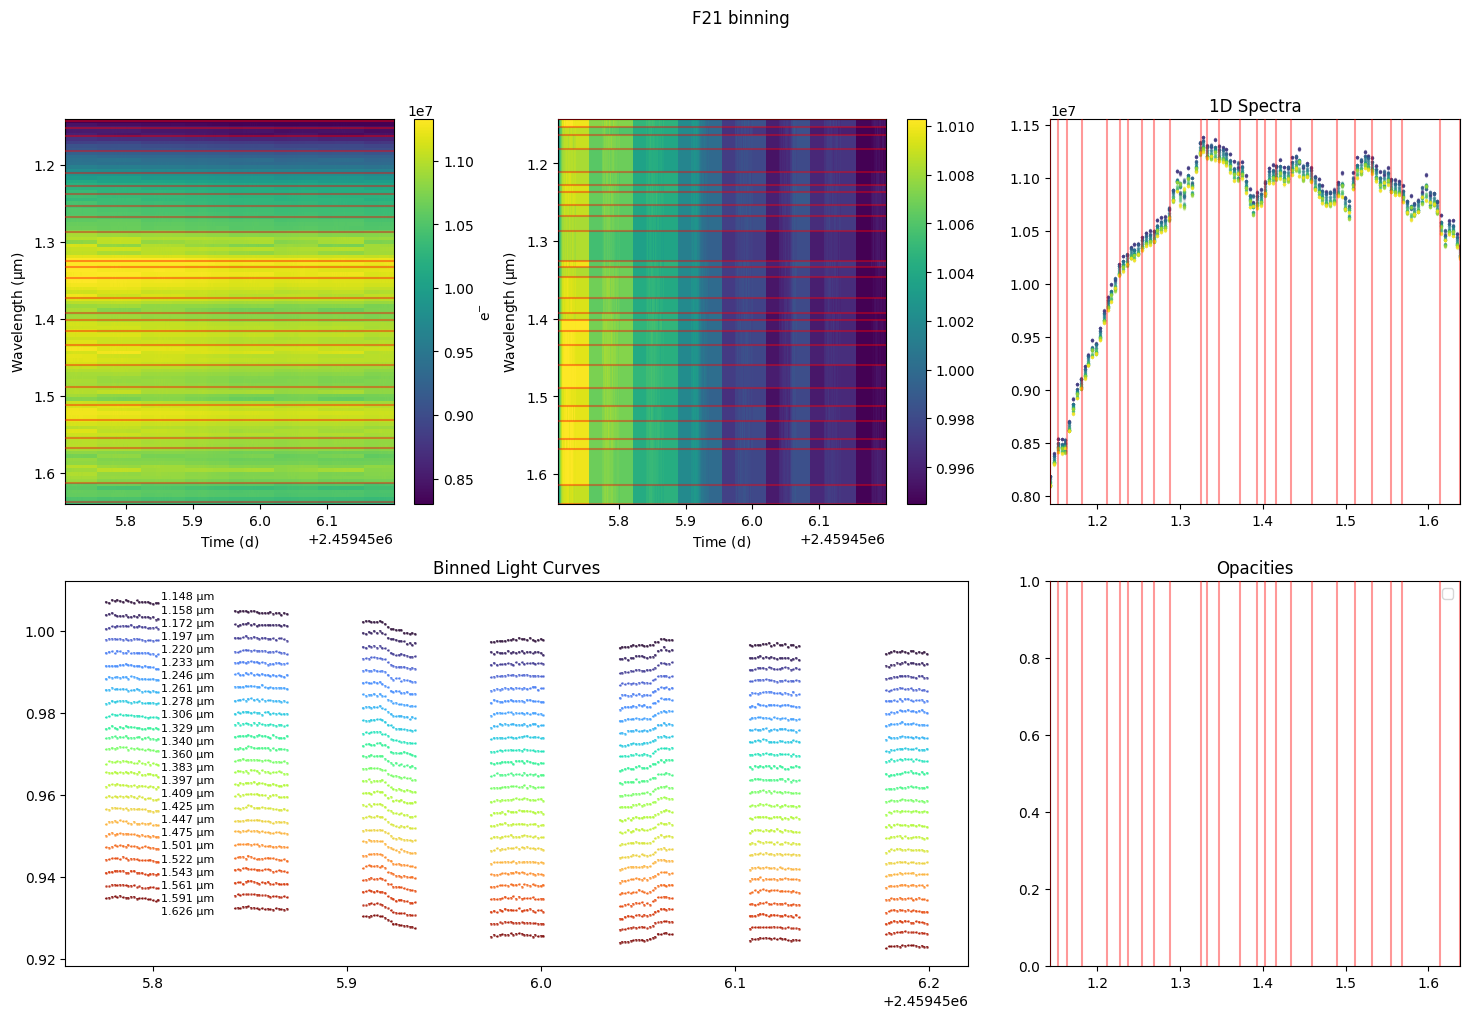

<Figure size 640x480 with 0 Axes>

In [6]:
for visit in ['F21']:
    # Extract exposure times and mid-transit times from the dictionary
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    expTime = visits[f'{visit}']['exp (s)'].value
    if visit == 'F21':
        bin_edges = F21_speclc_bin_edges.value
    if visit == 'S22':
        bin_edges = S22_speclc_bin_edges.value

    # Create a custom grid layout
    fig = plt.figure(figsize=(18, 11))
    plt.tight_layout()
    plt.suptitle(f'{visit} binning')

    # Define the grid layout
    ax1 = plt.subplot2grid((2, 3), (0, 0))  # Top left (imshow 1)
    ax2 = plt.subplot2grid((2, 3), (0, 1))  # Top middle (imshow 2)
    ax3 = plt.subplot2grid((2, 3), (1, 0), colspan=2)  # Bottom left (merged plot)
    ax4 = plt.subplot2grid((2, 3), (0, 2))  # Top right (1D Spectra)
    ax5 = plt.subplot2grid((2, 3), (1, 2))  # Bottom right (Opacities)

    # Set titles
    ax4.set_title('1D Spectra')
    ax5.set_title('Opacities')
    ax3.set_title('Binned Light Curves')

    for edge in bin_edges:
        ax1.axhline(edge, color='r', zorder=100,alpha=0.4)
        ax2.axhline(edge, color='r', zorder=100,alpha=0.4)
        ax5.axvline(edge, color='r', zorder=100,alpha=0.4)
        ax4.axvline(edge, color='r', zorder=100,alpha=0.4)

    # for i, spec in enumerate(species):
    #     op = binned_opacities[i](600, 0.01)  # cm2 / g
    #     col_idx = chem.get_column_index(species_name=spec)
    #     species_weight = weights[col_idx] / mmw_neptune
    #     abund_weighted_opacity = op * species_weight * vmr[:, col_idx]
    #     ax5.semilogy(np.geomspace(0.81, 1.64, 200), abund_weighted_opacity[0], label=spec)
    # ax5.set_xlim(bin_edges[0], bin_edges[-1])

    # for direction in ['Forward', 'Reverse']:
    # Read in the trimmed rainbows
    # rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")

    print(len(rainbow.wavelength))
    print(rainbow.wavelength)
    # print(np.nanmedian(rainbow.wavelength.value[:-1]-rainbow.wavelength.value[1:]) )
    binned = rainbow.normalize().bin(wavelength_edges=bin_edges * u.micron)
    img_date = binned.time.value
    orbit = np.zeros_like(img_date)

    # if direction == 'Forward':
    rainbow.pcolormesh(ax=ax1)
    binned.pcolormesh(ax=ax2)

    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]

    for o in np.unique(orbit[orbit >= 0]):
        first_index = np.where(orbit == o)[0][0]
        rainbow.flux.value[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        binned.flux.value[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    
    rainbow.flux.value[:, orbit == 0] = np.nan
    binned.flux.value[:, orbit == 0] = np.nan

    for i in range(len(rainbow.time.value)):
        # ax4.scatter(binned.wavelength, binned.flux[:, i].value, zorder=100, s=4, alpha=0.8,
        #             color='k')
        ax4.scatter(rainbow.wavelength, rainbow.flux[:, i].value, alpha=0.1, s=2,
                    color=plt.cm.viridis((rainbow.time.value[i] - rainbow.time.value.min()) / np.ptp(rainbow.time.value)))

    for i in range(len(binned.wavelength.value)):
        flux_i = binned.flux[i, :].value  # Strip units from flux
        unc_i = binned.uncertainty[i,:].value
        unc_i /= np.nanmean(flux_i)
        flux_i /= np.nanmean(flux_i)
        
        ax3.errorbar(binned.time, flux_i - (0.003 * i), yerr=unc_i, fmt='o', ms=1, alpha=0.6,
                     color=plt.cm.turbo((binned.wavelength.value[i] - binned.wavelength.value.min()) / np.ptp(binned.wavelength.value)))

    # Calculate central wavelengths for each bin
    central_wavelengths = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)]

    # Annotate the bottom row plot with central wavelengths
    x_pos = np.nanmean(binned.time.value)-0.145  # First time point
    for i in range(len(binned.wavelength.value)):
        # Position the annotation near the first point of each light curve
        y_pos = np.nanmax(binned.flux[0,:].value)-0.0032*i  # First flux point, adjusted for offset (strip units)
        ax3.annotate(f'{central_wavelengths[i]:.3f} µm',[x_pos,y_pos],fontsize=8)

    ax4.set_xlim(bin_edges[0], bin_edges[-1])
    ax5.set_xlim(bin_edges[0], bin_edges[-1])
    ax5.set_ylim(1e-20,None)
    ax5.legend()

    # Adjust spacing between subplots
    # plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.1, hspace=0)

    plt.savefig(f'../../figs/{visit}_binned_lcs_testing.png',dpi=400)
    plt.show()
    plt.clf()

In [ ]:
for visit in ['S22','F21']:
    # Extract exposure times and mid-transit times from the dictionary
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    expTime = visits[f'{visit}']['exp (s)'].value

    # for direction in ['Forward', 'Reverse']:
    #     # Read in the trimmed rainbows
    #     rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
    #     # print(len(rainbow.wavelength))
    #     # print(np.diff(rainbow.wavelength))
    #     for i,lam in enumerate(rainbow.wavelength):
    #         plt.figure(figsize=(4.5,2))
    #         plt.title(f'{visit} {direction} {lam:.5f} micron')
    #         plt.scatter(rainbow.time,rainbow.flux[i]/np.nanmean(rainbow.flux[i]),s=1.5)
    #         plt.show()
    #         plt.clf()

    'Read in the trimmed rainbows from process_pacman_spectra.ipynb'
    data_fluxes = []
    rel_spec_errs = []
    img_dates = []
    wave_arrays = []
    for direction in ['Forward','Reverse']:
        rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
        img_dates.append(rainbow.time.value)
        binned_rainbow = rainbow#.normalize().bin(wavelength_edges=spec_bin_edges)
        wave_arrays.append(binned_rainbow.wavelength.value)
        data_fluxes.append(binned_rainbow.flux.value)
        rel_spec_errs.append(binned_rainbow.uncertainty.value)
    wavelengths = np.nanmean(wave_arrays, axis=0)
    img_date = np.nanmean(img_dates,axis=0)
    data_flux = np.nansum(data_fluxes,axis=0)
    relative_err = np.sqrt(data_flux)/data_flux
    time_from_T0 = img_date - predicted_T0

    for i,lam in enumerate(wavelengths):
        print(f'{wave_arrays[0][i]:.6f}, {wave_arrays[1][i]:.6f}, {wavelengths[i]:.6f}')
    
    for i,lam in enumerate(wavelengths):
        plt.figure(figsize=(4.5,2))
        plt.title(f'{visit} {lam:.5f} micron')
        plt.errorbar(img_date,data_fluxes[0][i]/np.nanmean(data_fluxes[0][i]),
                     yerr = np.sqrt(data_fluxes[0][i])/data_fluxes[0][i],
                     ms=1.0,fmt='o',color='darkred')
        plt.errorbar(img_date,data_fluxes[1][i]/np.nanmean(data_fluxes[1][i]),
                     yerr = np.sqrt(data_fluxes[1][i])/data_fluxes[1][i],
                     ms=1.0,fmt='o',color='pink')
        plt.show()
        plt.clf()

In [ ]:
for visit in ['F21', 'S22']:
    # Extract exposure times and mid-transit times from the dictionary
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    expTime = visits[f'{visit}']['exp (s)'].value

    # Create a custom grid layout
    fig = plt.figure(figsize=(15, 9))
    plt.tight_layout()
    plt.suptitle(f'{visit} binning')

    # Define the grid layout
    ax1 = plt.subplot2grid((2, 3), (0, 0))  # Top left (imshow 1)
    ax2 = plt.subplot2grid((2, 3), (0, 1))  # Top middle (imshow 2)
    ax3 = plt.subplot2grid((2, 3), (1, 0), colspan=2)  # Bottom left (merged plot)
    ax4 = plt.subplot2grid((2, 3), (0, 2))  # Top right (1D Spectra)
    ax5 = plt.subplot2grid((2, 3), (1, 2))  # Bottom right (Opacities)

    # Set titles
    ax4.set_title('1D Spectra')
    ax5.set_title('Opacities')
    ax3.set_title('Binned Light Curves')

    for edge in bin_edges:
        ax1.axhline(edge, color='r', zorder=100,alpha=0.6)
        ax2.axhline(edge, color='r', zorder=100,alpha=0.6)
        ax5.axvline(edge, color='r', zorder=100,alpha=0.6)
        ax4.axvline(edge, color='r', zorder=100,alpha=0.6)

    for i, spec in enumerate(species):
        op = binned_opacities[i](600, 0.01)  # cm2 / g
        col_idx = chem.get_column_index(species_name=spec)
        species_weight = weights[col_idx] / mmw_neptune
        abund_weighted_opacity = op * species_weight * vmr[:, col_idx]
        ax5.semilogy(np.geomspace(0.81, 1.64, 150), abund_weighted_opacity[0], label=spec)
    ax5.set_xlim(bin_edges[0], bin_edges[-1])

    for direction in ['Forward', 'Reverse']:
        # Read in the trimmed rainbows
        rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
        print(len(rainbow.wavelength))
        print(rainbow.wavelength)
        # print(np.nanmedian(rainbow.wavelength.value[:-1]-rainbow.wavelength.value[1:]) )
        binned = rainbow.normalize().bin(wavelength_edges=bin_edges * u.micron)
        img_date = binned.time.value
        orbit = np.zeros_like(img_date)

        if direction == 'Forward':
            rainbow.imshow(ax=ax1)
            binned.imshow(ax=ax2)

        for j in range(len(img_date)):
            if j >= 1:
                if (img_date[j] - img_date[j - 1]) > 0.01:
                    orbit[j] = (orbit[j - 1] + 1)
                else:
                    orbit[j] = orbit[j - 1]

        for o in np.unique(orbit[orbit >= 0]):
            first_index = np.where(orbit == o)[0][0]
            rainbow.flux.value[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
            binned.flux.value[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        
        rainbow.flux.value[:, orbit == 0] = np.nan
        binned.flux.value[:, orbit == 0] = np.nan

        for i in range(len(rainbow.time.value)):
            ax4.scatter(binned.wavelength, binned.flux[:, i].value, zorder=100, s=4, alpha=0.8,
                        color='k')
            ax4.scatter(rainbow.wavelength, rainbow.flux[:, i].value, alpha=0.1, s=2,
                        color=plt.cm.viridis((rainbow.time.value[i] - rainbow.time.value.min()) / np.ptp(rainbow.time.value)))

        for i in range(len(binned.wavelength.value)):
            flux_i = binned.flux[i, :].value  # Strip units from flux
            flux_i /= np.nanmean(flux_i)
            ax3.errorbar(binned.time, flux_i - (0.002 * i), yerr=200e-6, fmt='o', ms=1, alpha=0.8,
                         color=plt.cm.turbo((binned.wavelength.value[i] - binned.wavelength.value.min()) / np.ptp(binned.wavelength.value)))

    # Calculate central wavelengths for each bin
    central_wavelengths = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)]

    # Annotate the bottom row plot with central wavelengths
    x_pos = np.nanmean(binned.time.value)-0.145  # First time point
    for i in range(len(binned.wavelength.value)):
        # Position the annotation near the first point of each light curve
        y_pos = np.nanmax(binned.flux[0,:].value)-0.002*i  # First flux point, adjusted for offset (strip units)
        ax3.annotate(f'{central_wavelengths[i]:.3f} µm',[x_pos,y_pos],fontsize=8)

    ax4.set_xlim(bin_edges[0], bin_edges[-1])
    ax5.set_xlim(bin_edges[0], bin_edges[-1])
    ax5.legend()

    # Adjust spacing between subplots
    # plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.1, hspace=0)

    plt.savefig(f'../figs/{visit}_binned_lcs_testing.png',dpi=300)
    plt.show()
    plt.clf()